In [23]:
import pandas as pd
import numpy as np

jpn = pd.read_excel("JPN Data.xlsx")
ind = pd.read_excel("IN_Data.xlsx")

print(jpn.head())
print(ind.head())

           ID  CURR_AGE GENDER     ANN_INCOME  AGE_CAR  PURCHASE
0  00001Q15YJ        50      M  445344.000000      439         0
1  00003I71CQ        35      M  107634.000000      283         0
2  00003N47FS        59      F  502786.666667      390         1
3  00005H41DE        43      M  585664.000000      475         0
4  00007E17UM        39      F  705722.666667      497         1
           ID  CURR_AGE GENDER  ANN_INCOME   DT_MAINT
0  20710B05XL        54      M     1425390 2018-04-20
1  89602T51HX        47      M     1678954 2018-06-08
2  70190Z52IP        60      M      931624 2017-07-31
3  25623V15MU        55      F     1106320 2017-07-31
4  36230I68CE        32      F      748465 2019-01-27


In [24]:
print("JPN Dataset Info:")
print(jpn.shape)
print(jpn.dtypes)

print("\nIND Dataset Info:")
print(ind.shape)
print(ind.dtypes)

JPN Dataset Info:
(40000, 6)
ID             object
CURR_AGE        int64
GENDER         object
ANN_INCOME    float64
AGE_CAR         int64
PURCHASE        int64
dtype: object

IND Dataset Info:
(70000, 5)
ID                    object
CURR_AGE               int64
GENDER                object
ANN_INCOME             int64
DT_MAINT      datetime64[ns]
dtype: object


In [25]:
print("JPN Missing Values:")
print(jpn.isnull().sum())

print("\nIND Missing Values:")
print(ind.isnull().sum())

JPN Missing Values:
ID            0
CURR_AGE      0
GENDER        0
ANN_INCOME    0
AGE_CAR       0
PURCHASE      0
dtype: int64

IND Missing Values:
ID            0
CURR_AGE      0
GENDER        0
ANN_INCOME    0
DT_MAINT      0
dtype: int64


In [26]:
print("JPN Duplicate Rows:", jpn.duplicated().sum())
print("IND Duplicate Rows:", ind.duplicated().sum())

JPN Duplicate Rows: 0
IND Duplicate Rows: 0


In [27]:
print("JPN Summary:")
print(jpn.describe())

print("\nIND Summary:")
print(ind.describe())

JPN Summary:
          CURR_AGE     ANN_INCOME       AGE_CAR      PURCHASE
count  40000.00000   40000.000000  40000.000000  40000.000000
mean      44.99745  359398.878050    359.080250      0.575775
std       11.82008  175109.262950    203.063724      0.494231
min       25.00000   70089.000000      1.000000      0.000000
25%       35.00000  219766.000000    235.000000      0.000000
50%       45.00000  337656.833333    331.000000      1.000000
75%       55.00000  464261.000000    444.000000      1.000000
max       65.00000  799970.666667   1020.000000      1.000000

IND Summary:
           CURR_AGE    ANN_INCOME                       DT_MAINT
count  70000.000000  7.000000e+04                          70000
mean      44.995314  1.148679e+06  2018-06-28 16:10:28.662856960
min       25.000000  3.000330e+05            2016-09-14 00:00:00
25%       35.000000  8.568238e+05            2018-03-15 00:00:00
50%       45.000000  1.125152e+06            2018-07-26 00:00:00
75%       55.000000  1.43

In [28]:
print("JPN Gender:")
print(jpn["GENDER"].value_counts())

print("\nJPN Purchase:")
print(jpn["PURCHASE"].value_counts())

print("\nIND Gender:")
print(ind["GENDER"].value_counts())

JPN Gender:
GENDER
M    22285
F    17715
Name: count, dtype: int64

JPN Purchase:
PURCHASE
1    23031
0    16969
Name: count, dtype: int64

IND Gender:
GENDER
M    35029
F    34971
Name: count, dtype: int64


In [29]:
print("JPN Unique IDs:", jpn["ID"].nunique(), "out of", len(jpn))
print("IND Unique IDs:", ind["ID"].nunique(), "out of", len(ind))

JPN Unique IDs: 40000 out of 40000
IND Unique IDs: 70000 out of 70000


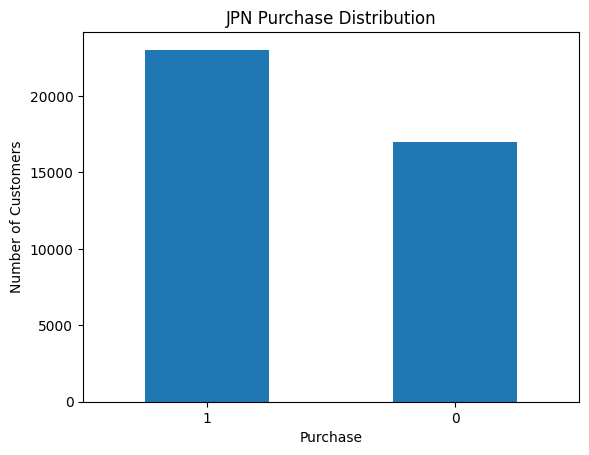

In [30]:
import matplotlib.pyplot as plt

jpn["PURCHASE"].value_counts().plot(kind="bar")

plt.title("JPN Purchase Distribution")
plt.xlabel("Purchase")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

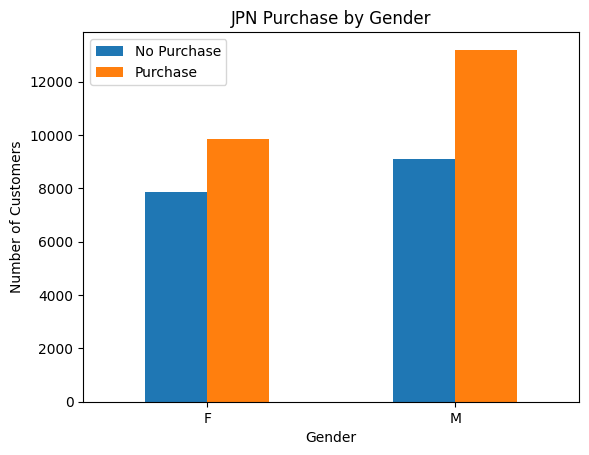

In [31]:
jpn.groupby("GENDER")["PURCHASE"].value_counts().unstack().plot(
    kind="bar"
)

plt.title("JPN Purchase by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(["No Purchase", "Purchase"])
plt.show()

In [32]:
purchase_rate = jpn.groupby("GENDER")["PURCHASE"].mean() * 100

print(purchase_rate)

GENDER
F    55.523568
M    59.210231
Name: PURCHASE, dtype: float64


In [33]:
print("JPN Purchase Rate:")
print(jpn["PURCHASE"].mean() * 100)

JPN Purchase Rate:
57.5775


In [34]:
print(ind.columns.tolist())

['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'DT_MAINT']


In [35]:
print("IND Gender Distribution:")
print(ind["GENDER"].value_counts())

IND Gender Distribution:
GENDER
M    35029
F    34971
Name: count, dtype: int64


In [36]:
print("IND Age Summary:")
print(ind["CURR_AGE"].describe())

IND Age Summary:
count    70000.000000
mean        44.995314
std         11.822122
min         25.000000
25%         35.000000
50%         45.000000
75%         55.000000
max         65.000000
Name: CURR_AGE, dtype: float64


In [37]:
print("IND Average Income by Gender:")
print(ind.groupby("GENDER")["ANN_INCOME"].mean())


IND Average Income by Gender:
GENDER
F    1.085948e+06
M    1.211305e+06
Name: ANN_INCOME, dtype: float64


# New Section EDA

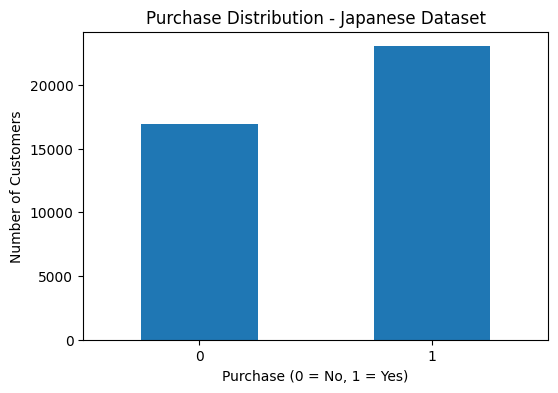

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

jpn["PURCHASE"].value_counts().sort_index().plot(kind="bar")

plt.title("Purchase Distribution - Japanese Dataset")
plt.xlabel("Purchase (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

Purchase Rate by Gender:
GENDER
F    55.523568
M    59.210231
Name: PURCHASE, dtype: float64


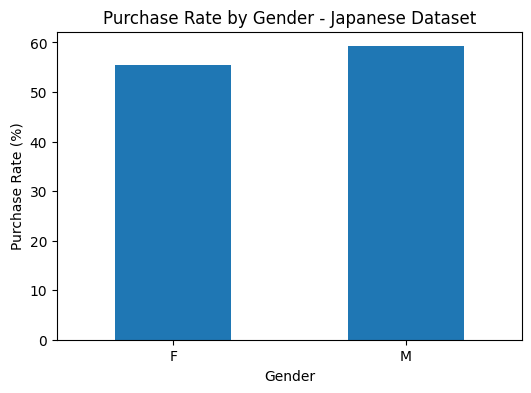

In [39]:
purchase_gender = jpn.groupby("GENDER")["PURCHASE"].mean() * 100

print("Purchase Rate by Gender:")
print(purchase_gender)

plt.figure(figsize=(6,4))
purchase_gender.plot(kind="bar")

plt.title("Purchase Rate by Gender - Japanese Dataset")
plt.xlabel("Gender")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)
plt.show()

Purchase Rate by Age Group:
AGE_GROUP
25-34    55.095150
35-44    60.869120
45-54    60.051203
55-65    54.587070
Name: PURCHASE, dtype: float64


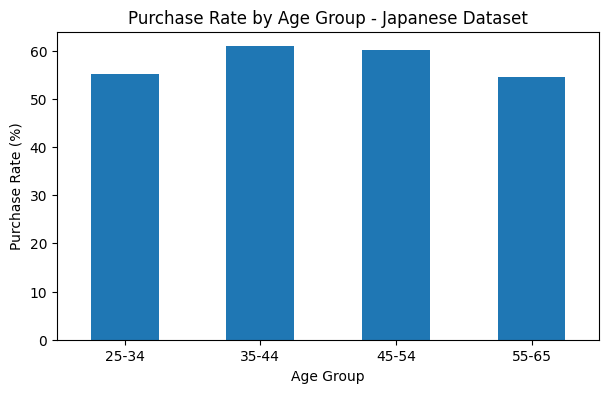

In [40]:
jpn["AGE_GROUP"] = pd.cut(
    jpn["CURR_AGE"],
    bins=[24, 34, 44, 54, 65],
    labels=["25-34", "35-44", "45-54", "55-65"]
)

age_purchase = jpn.groupby(
    "AGE_GROUP",
    observed=False
)["PURCHASE"].mean() * 100

print("Purchase Rate by Age Group:")
print(age_purchase)

plt.figure(figsize=(7,4))
age_purchase.plot(kind="bar")

plt.title("Purchase Rate by Age Group - Japanese Dataset")
plt.xlabel("Age Group")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)
plt.show()

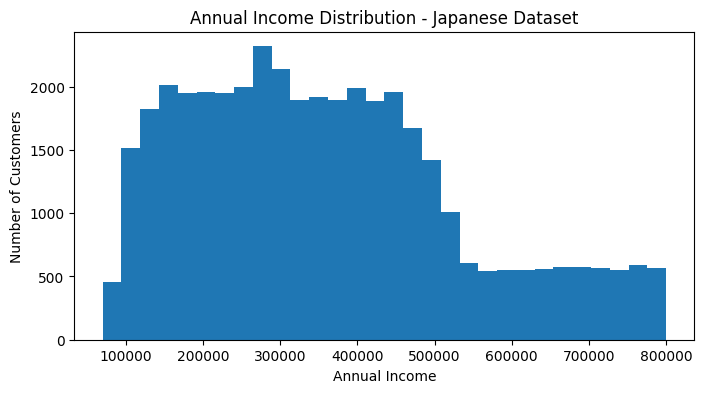

In [41]:
plt.figure(figsize=(8,4))

plt.hist(jpn["ANN_INCOME"], bins=30)

plt.title("Annual Income Distribution - Japanese Dataset")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")

plt.show()

<Figure size 700x400 with 0 Axes>

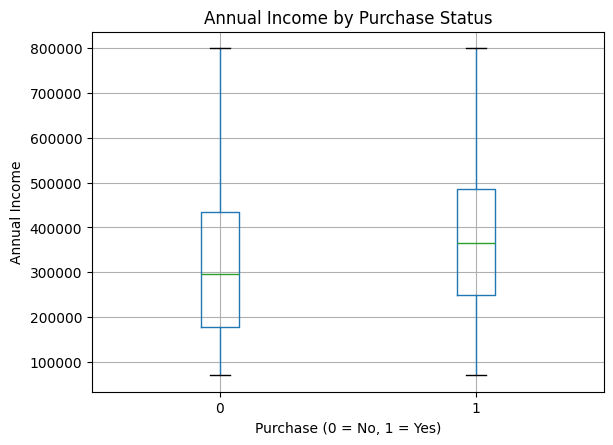

In [42]:
plt.figure(figsize=(7,4))

jpn.boxplot(
    column="ANN_INCOME",
    by="PURCHASE"
)

plt.title("Annual Income by Purchase Status")
plt.suptitle("")
plt.xlabel("Purchase (0 = No, 1 = Yes)")
plt.ylabel("Annual Income")

plt.show()

# New Section Machine Learn Model


In [43]:
X = jpn[["CURR_AGE", "GENDER", "ANN_INCOME"]]
y = jpn["PURCHASE"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   CURR_AGE GENDER     ANN_INCOME
0        50      M  445344.000000
1        35      M  107634.000000
2        59      F  502786.666667
3        43      M  585664.000000
4        39      F  705722.666667

Target:
0    0
1    0
2    1
3    0
4    1
Name: PURCHASE, dtype: int64


In [44]:
X = X.copy()

X["GENDER"] = X["GENDER"].map({"F": 0, "M": 1})

print(X.head())

   CURR_AGE  GENDER     ANN_INCOME
0        50       1  445344.000000
1        35       1  107634.000000
2        59       0  502786.666667
3        43       1  585664.000000
4        39       0  705722.666667


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 32000
Testing samples: 8000


In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [47]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


In [48]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("First 20 predictions:")
print(y_pred[:20])

print("\nFirst 20 probabilities:")
print(y_prob[:20])

First 20 predictions:
[1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1]

First 20 probabilities:
[0.54767516 0.59758985 0.59827898 0.50114807 0.5404775  0.50739445
 0.545584   0.64261726 0.59434147 0.64612575 0.51917024 0.59018432
 0.63003178 0.46975609 0.46263003 0.64409919 0.61637127 0.50971131
 0.56689252 0.60531435]


In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Model Performance")
print("-----------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Performance
-----------------
Accuracy : 0.61325
Precision: 0.6180143615360599
Recall   : 0.8595310464611376
F1 Score : 0.7190337813294587
ROC-AUC  : 0.6045057675021512

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.28      0.38      3394
           1       0.62      0.86      0.72      4606

    accuracy                           0.61      8000
   macro avg       0.61      0.57      0.55      8000
weighted avg       0.61      0.61      0.58      8000



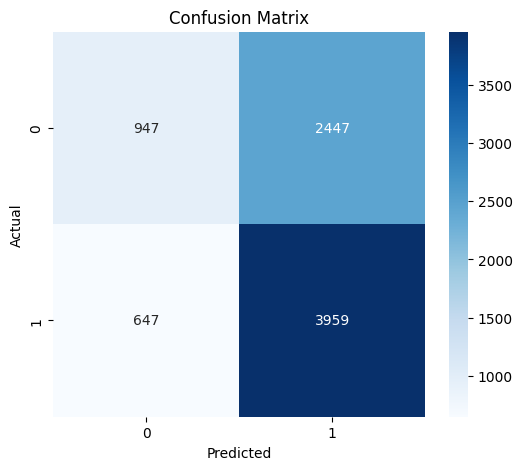

Confusion Matrix:
[[ 947 2447]
 [ 647 3959]]


In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix:")
print(cm)

In [51]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coefficients)

      Feature  Coefficient
0    CURR_AGE    -0.089461
1      GENDER     0.088131
2  ANN_INCOME     0.383981


In [52]:
coefficients["Odds_Ratio"] = np.exp(coefficients["Coefficient"])

print(coefficients)

      Feature  Coefficient  Odds_Ratio
0    CURR_AGE    -0.089461    0.914424
1      GENDER     0.088131    1.092131
2  ANN_INCOME     0.383981    1.468118


In [53]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:")
print(cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean())

Cross-validation scores:
[0.61890625 0.615625   0.62359375 0.62140625 0.61625   ]

Mean CV Accuracy: 0.61915625


# New Section India Market pred.

In [59]:
ind_model = ind[["CURR_AGE", "GENDER", "ANN_INCOME"]].copy()

ind_model["GENDER"] = ind_model["GENDER"].map({"F": 0, "M": 1})

print(ind_model.head())

   CURR_AGE  GENDER  ANN_INCOME
0        54       1     1425390
1        47       1     1678954
2        60       1      931624
3        55       0     1106320
4        32       0      748465


In [55]:
ind_scaled = scaler.transform(ind_model)

ind["PURCHASE_PROBABILITY"] = model.predict_proba(ind_scaled)[:, 1]
ind["PREDICTED_PURCHASE"] = model.predict(ind_scaled)

print(ind.head())

           ID  CURR_AGE GENDER  ANN_INCOME   DT_MAINT  PURCHASE_PROBABILITY  \
0  20710B05XL        54      M     1425390 2018-04-20              0.935266   
1  89602T51HX        47      M     1678954 2018-06-08              0.963744   
2  70190Z52IP        60      M      931624 2017-07-31              0.823628   
3  25623V15MU        55      F     1106320 2017-07-31              0.856331   
4  36230I68CE        32      F      748465 2019-01-27              0.763816   

   PREDICTED_PURCHASE  
0                   1  
1                   1  
2                   1  
3                   1  
4                   1  


In [56]:
potential_customers = (ind["PREDICTED_PURCHASE"] == 1).sum()
total_indian_customers = len(ind)
potential_percentage = (potential_customers / total_indian_customers) * 100

print("Total Indian Customers:", total_indian_customers)
print("Potential Customers:", potential_customers)
print("Potential Customer Percentage:", potential_percentage)

Total Indian Customers: 70000
Potential Customers: 69946
Potential Customer Percentage: 99.92285714285714


In [57]:
print(ind["PURCHASE_PROBABILITY"].describe())

count    70000.000000
mean         0.856092
std          0.102677
min          0.486839
25%          0.804819
50%          0.881144
75%          0.936348
max          0.983109
Name: PURCHASE_PROBABILITY, dtype: float64


In [58]:
target = 12000

target_percentage = (target / total_indian_customers) * 100

print("Target:", target)
print("Target as percentage of Indian dataset:", target_percentage)

if potential_customers >= target:
    print("The estimated potential customer count exceeds the 12,000 target.")
else:
    print("The estimated potential customer count is below the 12,000 target.")

Target: 12000
Target as percentage of Indian dataset: 17.142857142857142
The estimated potential customer count exceeds the 12,000 target.


# indian market analysis

In [60]:
ind_gender = ind["GENDER"].value_counts()

print("Indian Customers by Gender:")
print(ind_gender)

Indian Customers by Gender:
GENDER
M    35029
F    34971
Name: count, dtype: int64


In [61]:
ind_income_gender = ind.groupby("GENDER")["ANN_INCOME"].mean()

print("Average Annual Income by Gender:")
print(ind_income_gender)

Average Annual Income by Gender:
GENDER
F    1.085948e+06
M    1.211305e+06
Name: ANN_INCOME, dtype: float64


In [62]:
ind_age_gender = ind.groupby("GENDER")["CURR_AGE"].mean()

print("Average Age by Gender:")
print(ind_age_gender)

Average Age by Gender:
GENDER
F    44.978468
M    45.012133
Name: CURR_AGE, dtype: float64


In [63]:
ind_potential_gender = ind.groupby("GENDER")["PREDICTED_PURCHASE"].sum()

print("Potential Customers by Gender:")
print(ind_potential_gender)

Potential Customers by Gender:
GENDER
F    34917
M    35029
Name: PREDICTED_PURCHASE, dtype: int64


Export data


In [64]:
ind.to_csv("India_Customer_Predictions.csv", index=False)
jpn.to_csv("Japan_Analysis.csv", index=False)

print("Files created successfully.")

Files created successfully.


In [65]:
from google.colab import files

files.download("India_Customer_Predictions.csv")
files.download("Japan_Analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>